In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("..")
print("at directory:", os.getcwd())

at directory: /Users/wilka/git/research/human-dyna-web/analysis_notebooks
changing to root directory
at directory: /Users/wilka/git/research/human-dyna-web


In [3]:
# !pip install -e libraries/housemaze -e libraries/nicewebrl -e libraries/jaxneurorl -r requirements.txt

In [4]:
import jax
import jax.numpy as jnp
import functools
from functools import partial
import numpy as np
from pprint import pprint
import glob
from glob import glob
import matplotlib.pyplot as plt
import polars as pl
from tqdm.notebook import tqdm


from housemaze.human_dyna import mazes
from housemaze import renderer
from housemaze import utils
from housemaze.human_dyna import multitask_env as maze
from housemaze.human_dyna import experiments as housemaze_experiments

from jaxneurorl import launcher

from simulations import housemaze_trainer
from analysis import data_loading
from analysis import download_data
from analysis import housemaze_utils as housemaze_analysis
from analysis import plots
from nicewebrl import dataframe

from nicewebrl import dataframe

from experiment_utils import SuccessTrackingAutoResetWrapper

wandb: WARNING `wandb.require('core')` is redundant as it is now the default behavior.
/Users/wilka/miniforge3/envs/preplay/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:118: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy


In [5]:
# data_dir = '/n/holylfs06/LABS/kempner_fellow_wcarvalho/results/jaxrl_result/housemaze_trainer'
data_dir = "/Users/wilka/git/research/results/human_dyna"

In [6]:
dummy_env_params = housemaze_analysis.get_params(mazes.big_practice_maze)
dummy_rng = jax.random.PRNGKey(42)
task_runner = maze.TaskRunner(task_objects=housemaze_analysis.task_objects)
base_env = maze.HouseMaze(
  task_runner=task_runner,
  num_categories=200,
)
env = utils.AutoResetWrapper(base_env)
nenvs = 25
example_timestep = env.reset(dummy_rng, dummy_env_params)

# Setup databases

For every algorithm, for every experiment, we will
1. load the algorithm
2. collect K=100 episodes for that algorithm on task objects, we can choose multiple or 1 task object. 
    we'll always use the 1st task object from the train and test sets
3. for each of these K episodes, we're going to create an entry inside a polars dataframe including (1) whether eval or not, (2) algorithm (3) experiment (4) room (5) task_idx

We'll want to options
1. if we reload this script, if possible load (a) algorithm df and (b) algorithm episodes from trajectory and don't recompute
3. option to force recomputation and overwrite data on disk


In the end, we'll have dfs for every algorithm and an episode dict which goes (alg:list). we'll use these to two subselect data for different algorithms. we'll write a small select function which takes in this merged df and this episode dict




We'll want to re-do this for users\

In [7]:
# !ls ~/git/research/results/human_dyna/model_data/*/save_data/*/*/*/analysis

In [8]:
# !rm -r ~/git/research/results/human_dyna/model_data/*/save_data/*/*/*/analysis

In [9]:
model_df_list = []
model_episodes_list = []

### Q-learning

In [10]:
exp = "exp2"
qlearning_dir = download_data.qlearning_dir
paths = f"{data_dir}/model_data/{qlearning_dir}/*"
paths = glob(paths)

for path in tqdm(paths):
  seed = path.split("/")[-1].split("=")[-1]
  algorithm = data_loading.load_algorithm(
    path=path,
    name="qlearning",
    make_fns=functools.partial(
      housemaze_trainer.get_qlearning_fns, num_categories=10000
    ),
    env=env,
    example_env_params=dummy_env_params,
    nenvs=nenvs,
  )
  df, episodes = housemaze_analysis.get_algorithm_data(
    algorithm=algorithm, exp=exp, overwrite=True, extra_info=dict(seed=seed)
  )
  model_df_list.append(df)
  model_episodes_list.extend(episodes)

  0%|          | 0/5 [00:00<?, ?it/s]

No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy


KeyboardInterrupt: 

/var/folders/xy/l2ynyz5d10x4c52rnkln7tp80000gr/T/ipykernel_88299/2620379054.py:1: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  def first(eps): return jax.tree_map(lambda x:x[0], eps)


eval,algo,exp,room,task,maze_name,seed
bool,str,str,i64,i64,str,i64
false,"""qlearning""","""exp2""",0,26,"""big_m3_maze1""",3
true,"""qlearning""","""exp2""",0,40,"""big_m3_maze1""",3
false,"""qlearning""","""exp2""",0,26,"""big_m2_maze2_onpath""",3
true,"""qlearning""","""exp2""",0,40,"""big_m2_maze2_onpath""",3
false,"""qlearning""","""exp2""",0,26,"""big_m2_maze2_offpath""",3


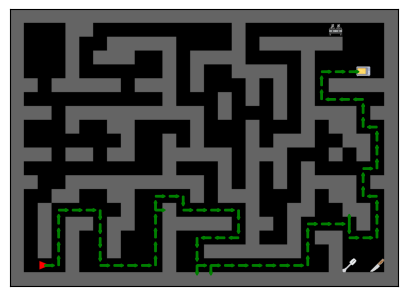

In [88]:
def first(eps):
  return jax.tree_map(lambda x: x[0], eps)


housemaze_analysis.render_path(first(episodes[0]))
df.head()

# Universal Successor Feature Approximators

In [89]:
from housemaze.human_dyna import sf_task_runner

task_runner_sf = sf_task_runner.TaskRunner(
  task_objects=housemaze_analysis.task_objects, vis_coeff=0.1, radius=5
)
sf_env = maze.HouseMaze(
  task_runner=task_runner_sf,
  num_categories=200,
)
sf_env = utils.AutoResetWrapper(sf_env)


exp = "exp2"
paths = f"{data_dir}/model_data/{download_data.sf_dir}/*"
paths = glob(paths)

for path in tqdm(paths):
  seed = path.split("/")[-1].split("=")[-1]
  algorithm = data_loading.load_algorithm(
    path=path,
    name="usfa",
    make_fns=functools.partial(
      housemaze_trainer.get_sf_fns, env=sf_env, env_params=dummy_env_params
    ),
    env=sf_env,
    example_env_params=dummy_env_params,
    nenvs=nenvs,
    config=dict(EVAL_TASK_SUPPORT="train"),
  )
  df, episodes = housemaze_analysis.get_algorithm_data(
    algorithm=algorithm,
    exp=exp,
    overwrite=False,
    extra_info=dict(seed=seed),
    data_task_runner=task_runner_sf,
  )
  model_df_list.append(df)
  model_episodes_list.extend(episodes)

  0%|          | 0/1 [00:00<?, ?it/s]

No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy


/var/folders/xy/l2ynyz5d10x4c52rnkln7tp80000gr/T/ipykernel_88299/2620379054.py:1: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  def first(eps): return jax.tree_map(lambda x:x[0], eps)


eval,algo,exp,room,task,maze_name,seed
bool,str,str,i64,i64,str,i64
false,"""usfa""","""exp2""",0,26,"""big_m1_maze3""",1
true,"""usfa""","""exp2""",0,40,"""big_m1_maze3""",1
false,"""usfa""","""exp2""",0,26,"""big_m2_maze2""",1
true,"""usfa""","""exp2""",0,40,"""big_m2_maze2""",1
false,"""usfa""","""exp2""",0,26,"""big_m3_maze1""",1


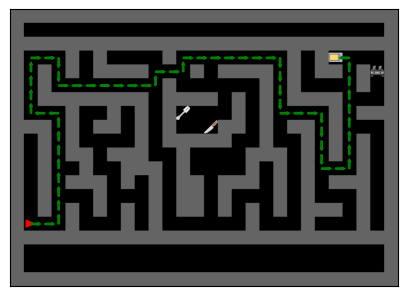

In [90]:
def first(eps):
  return jax.tree_map(lambda x: x[0], eps)


housemaze_analysis.render_path(first(episodes[0]))
df.head()

### Dyna-Q

In [91]:
exp = "exp2"
# dyna_dir = f'ql/save_data/ql-21/exp={exp}'
dyna_dir = download_data.dyna_dir
paths = f"{data_dir}/model_data/{dyna_dir}/*"
paths = glob(paths)

for path in tqdm(paths):
  seed = path.split("/")[-1].split("=")[-1]
  algorithm = data_loading.load_algorithm(
    path=path,
    name="dynaq_shared",
    make_fns=functools.partial(
      housemaze_trainer.get_dynaq_fns,
      env=env,
      env_params=dummy_env_params,
      task_objects=housemaze_analysis.task_objects,
    ),
    env=env,
    example_env_params=dummy_env_params,
    nenvs=nenvs,
  )
  df, episodes = housemaze_analysis.get_algorithm_data(
    algorithm=algorithm, exp=exp, overwrite=False, extra_info=dict(seed=seed)
  )
  model_df_list.append(df)
  model_episodes_list.extend(episodes)

  0%|          | 0/2 [00:00<?, ?it/s]

No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy
No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy


/var/folders/xy/l2ynyz5d10x4c52rnkln7tp80000gr/T/ipykernel_88299/2620379054.py:1: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  def first(eps): return jax.tree_map(lambda x:x[0], eps)


eval,algo,exp,room,task,maze_name,seed
bool,str,str,i64,i64,str,i64
false,"""dynaq_shared""","""exp2""",0,26,"""big_m3_maze1""",2
true,"""dynaq_shared""","""exp2""",0,40,"""big_m3_maze1""",2
false,"""dynaq_shared""","""exp2""",0,26,"""big_m2_maze2_onpath""",2
true,"""dynaq_shared""","""exp2""",0,40,"""big_m2_maze2_onpath""",2
false,"""dynaq_shared""","""exp2""",0,26,"""big_m2_maze2_offpath""",2


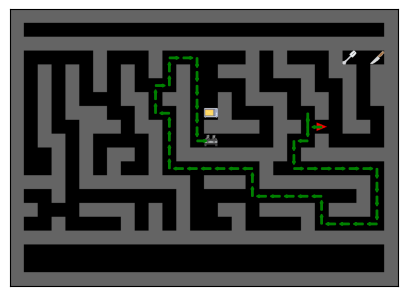

In [92]:
housemaze_analysis.render_path(first(episodes[-1]))
df.head()

### BFS/DFS

In [93]:
for algorithm in ["bfs", "dfs"]:
  df, episodes = housemaze_analysis.get_search_data(
    algorithm=algorithm,
    env=env,
    exp="exp2",
    base_path=f"{data_dir}/search_algos",
    budget=None,
    overwrite=False,
    searches=100,
  )
  model_df_list.append(df)
  model_episodes_list.extend(episodes)

No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy
No file specified for groups.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/human_dyna/list_of_groups.npy


/var/folders/xy/l2ynyz5d10x4c52rnkln7tp80000gr/T/ipykernel_88299/2620379054.py:1: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  def first(eps): return jax.tree_map(lambda x:x[0], eps)


eval,algo,exp,room,task,budget,maze_name
bool,str,str,i64,f64,str,str
false,"""dfs""","""exp2""",0,26.0,null,"""big_m2_maze2"""
true,"""dfs""","""exp2""",0,40.0,null,"""big_m2_maze2"""
false,"""dfs""","""exp2""",0,26.0,null,"""big_m3_maze1"""
true,"""dfs""","""exp2""",0,40.0,null,"""big_m3_maze1"""
false,"""dfs""","""exp2""",0,26.0,null,"""big_m1_maze3_shortcut"""


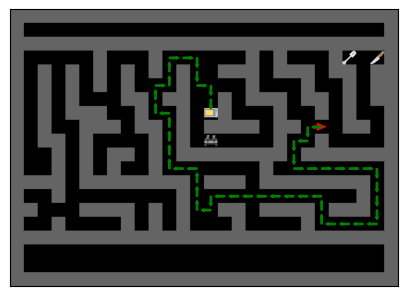

In [94]:
housemaze_analysis.render_path(first(episodes[0]))
df.head()

## put all model things together now

In [95]:
model_df = (
  pl.concat(model_df_lisdat, how="diagonal_relaxed")
  .with_row_count(name="row_number")
  .with_columns(pl.col("row_number").alias("index"))
  .drop("row_number")
)
model_df = dataframe.DataFrame(
  df=model_df,
  episodes=model_episodes_list,
)
model_df.head()

/var/folders/xy/l2ynyz5d10x4c52rnkln7tp80000gr/T/ipykernel_88299/1099679968.py:2: DeprecationWarning: `DataFrame.with_row_count` is deprecated. Use `with_row_index` instead. Note that the default column name has changed from 'row_nr' to 'index'.
  pl.concat(model_df_list, how="diagonal_relaxed")


index,eval,algo,exp,room,task,maze_name,seed,budget
u32,bool,str,str,i64,f64,str,i64,str
0,false,"""qlearning""","""exp2""",0,26.0,"""big_m3_maze1""",1,null
1,true,"""qlearning""","""exp2""",0,40.0,"""big_m3_maze1""",1,null
2,false,"""qlearning""","""exp2""",0,26.0,"""big_m2_maze2_onpath""",1,null
3,true,"""qlearning""","""exp2""",0,40.0,"""big_m2_maze2_onpath""",1,null
4,false,"""qlearning""","""exp2""",0,26.0,"""big_m2_maze2_offpath""",1,null


# Human data

In [7]:
# Define searches
data_dir = "/Users/wilka/git/research/results/human_dyna/"

searches = {
  "Paths": f"{data_dir}/user_data/*exps*/*v1*paths*.json",
  "Start": f"{data_dir}/user_data/*exps*/*v1*start*.json",
  "Plan (Tell)": f"{data_dir}/user_data/*exps*/*v1*r1-t0-plan*.json",
  "Plan (Don't Tell)": f"{data_dir}/user_data/*exps*/*v1*r0-t0-plan*.json",
  "Shortcut": f"{data_dir}/user_data/*exps*/*v1*shortcut*.json",
}

valid_files = data_loading.get_valid_files(searches, verbose=True, plot=False)
len(valid_files)

Paths: 23/23 valid files
Start: 25/25 valid files
User 3342618999 > 3 std. x: 65.59241666666667, mean: 19.95354266666667, 3*std: 56.937940882674134
Plan (Tell): 24/25 valid files
Plan (Don't Tell): 25/25 valid files
User 3202887523 > 3 std. x: 52.96695, mean: 19.95556597222222, 3*std: 45.97320455351084
Shortcut: 23/24 valid files


120

In [8]:
web_env = SuccessTrackingAutoResetWrapper(base_env)
example_web_timestep = web_env.reset(dummy_rng, dummy_env_params)

In [424]:
# %debug
initial_user_df = data_loading.make_all_episode_data(
  files=valid_files,
  example_timestep=example_web_timestep,
  overwrite_episode_info=True,
  # debug=True
)


def bad_episode(e):
  empty = len(e.actions) == 0
  empty |= (np.array(e.actions[0]) == -1).any()
  remove = empty
  return remove


# remove episodes with there are no actions or the only action is a time-out (==-1)
inital_user_df = inital_user_df.filter(episode_filter=bad_episode)

initial_user_df.head()

/Users/wilka/miniforge3/envs/preplay/lib/python3.10/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


Combining results:   0%|          | 0/120 [00:00<?, ?it/s]

index,maze,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,user_id,age,sex,user,debug,exp_name,version,tell_reuse,timer,reversal,success,path_length,termination,first_rt,avg_rt,total_rt
u32,str,i64,str,str,i64,i64,i64,bool,i64,i64,i64,i64,str,i64,i64,str,i64,i64,i64,str,f64,i64,f64,f64,f64,f64
0,"""big_m3_maze1_(F,T)""",0,"""big_m3_maze1""","""reusing longer of two paths wh…",3,0,1,false,31,1,3259014651,46,"""Female""",3259014651,0,"""exp5-v1-r1-t0-paths""",1,1,0,"""F,T""",1.0,40,1.0,1.119,0.3365,13.460001
1,"""big_m3_maze1_(F,T)""",0,"""big_m3_maze1""","""reusing longer of two paths wh…",3,1,2,false,31,1,3259014651,46,"""Female""",3259014651,0,"""exp5-v1-r1-t0-paths""",1,1,0,"""F,T""",1.0,38,1.0,1.816,0.447368,17.0
2,"""big_m3_maze1_(F,T)""",0,"""big_m3_maze1""","""reusing longer of two paths wh…",3,2,3,false,13,0,3259014651,46,"""Female""",3259014651,0,"""exp5-v1-r1-t0-paths""",1,1,0,"""F,T""",1.0,9,1.0,2.042,0.485778,4.372
3,"""big_m3_maze1_(F,T)""",0,"""big_m3_maze1""","""reusing longer of two paths wh…",3,3,4,false,13,0,3259014651,46,"""Female""",3259014651,0,"""exp5-v1-r1-t0-paths""",1,1,0,"""F,T""",1.0,103,1.0,1.571,0.561097,57.792992
4,"""big_m3_maze1_(F,T)""",0,"""big_m3_maze1""","""reusing longer of two paths wh…",3,4,5,false,31,1,3259014651,46,"""Female""",3259014651,0,"""exp5-v1-r1-t0-paths""",1,1,0,"""F,T""",1.0,61,1.0,1.739,0.383885,23.417004


In [425]:
user_df = plots.add_reuse_columns(initial_user_df)
# user_df.filter(manipulation=3, eval=True)['reuse'].head()  # test

# Filtering

(only filtering eval trials here)

(A) Paths + (B) Shortcut filtering (only one eval measurement per trial)
- For every user: if {first RT, avg RT} is > 3 STD

(C) Off-, On-path (D) Juncture filtering (two paired eval measurements per trial)
- For every user:
    For every maze:
        

In [293]:
episodes = model_df.filter(algo="bfs", maze_name="big_m1_maze3_shortcut").episodes
episode = first(episodes)[0]
in_episode = housemaze.get_in_episode(episode.timesteps)
actions = episode.actions[in_episode][:-1]
optimal_length = len(actions)
# housemaze.render_path(first(episodes[0]))

/var/folders/xy/l2ynyz5d10x4c52rnkln7tp80000gr/T/ipykernel_88299/2620379054.py:1: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  def first(eps): return jax.tree_map(lambda x:x[0], eps)


In [310]:
filtered_df = user_df
for manipulation in [1, 2, 3, 4]:
  print("=" * 20, "manipulation", manipulation)
  filtered_df = plots.filter_outliers(
    df=filtered_df,
    filter_settings=dict(manipulation=manipulation, eval=True),
    filter_columns=["path_length"],
    # filter_columns=['path_length'],
  )
# filtered_df.filter(manipulation=1, eval=True)['path_length'].max()

==================== manipulation 1
Filtered 8 outliers from 8917 rows using iqr method
	36431270. path_length:230 	(bounds: 16.5 to 148.5)
	36431270. path_length:151 	(bounds: 16.5 to 148.5)
	36431270. path_length:173 	(bounds: 16.5 to 148.5)
	322916660. path_length:190 	(bounds: 16.5 to 148.5)
	3903080245. path_length:179 	(bounds: 16.5 to 148.5)
	3903080245. path_length:163 	(bounds: 16.5 to 148.5)
	3903080245. path_length:153 	(bounds: 16.5 to 148.5)
	129575991. path_length:373 	(bounds: 16.5 to 148.5)
Users removed: {'36431270', '3903080245', '129575991', '322916660'}
==================== manipulation 2
Filtered 14 outliers from 8909 rows using iqr method
	2140518989. path_length:142 	(bounds: 20.0 to 104.0)
	2140518989. path_length:136 	(bounds: 20.0 to 104.0)
	2140518989. path_length:121 	(bounds: 20.0 to 104.0)
	2040342950. path_length:169 	(bounds: 20.0 to 104.0)
	2040342950. path_length:147 	(bounds: 20.0 to 104.0)
	1733670245. path_length:106 	(bounds: 20.0 to 104.0)
	137208

# Eval statistics

In [12]:
from IPython.display import Markdown, display
from analysis import housemaze_utils as housemaze
from analysis import plots
from analysis.plots import success_or_not_terminate, success

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Filtered 32 data points
Filtered 33 data points
Filtered 32 data points
Filtered 29 data points
Filtered 29 data points
Filtered 31 data points
Filtered 29 data points
Filtered 28 data points
Filtered 28 data points
Filtered 40 data points
Filtered 31 data points
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Filtered 28 data points
Filtered 36 data points
Filtered 31 data points
Filtered 57 data points
Filtered 30 data points
Filtered 32 data points
Filtered 52 data points
Filtered 28 data points
Filtered 29 data points
Filtered 43 data points
No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Filtered 35 data points
Filtered 32 data points
Filtered 28 data points
Filtered 28 data points
Filtered 30 data po

## (A) Paths manipulation (3)

In [485]:
settings = dict(manipulation=3, eval=True)
m3_df = plots.filter_outliers(
  df=user_df,
  filter_settings=settings,
  filter_columns=["path_length", "avg_rt"],
)
# for val in ['path_length', 'first_rt', 'avg_rt']:
#     plots.coplot_dists(user_df, filtered_df, val, settings)

Filtered 12 outliers from 92 rows using iqr method
	1443920885. path_length:167 	(bounds: 48.0 to 136.0)
	1443920885. path_length:148 	(bounds: 48.0 to 136.0)
	3652289292. path_length:180 	(bounds: 48.0 to 136.0)
	3652289292. path_length:211 	(bounds: 48.0 to 136.0)
	3657979164. avg_rt:1.0061445236206055 	(bounds: 0.04660837724804878 to 0.5481382198631763)
	530036071. avg_rt:0.553138256072998 	(bounds: 0.04660837724804878 to 0.5481382198631763)
	530036071. avg_rt:0.6515196561813354 	(bounds: 0.04660837724804878 to 0.5481382198631763)
	2838747012. path_length:164 	(bounds: 48.0 to 136.0)
	2265358324. path_length:426 	(bounds: 48.0 to 136.0)
	2265358324. path_length:335 	(bounds: 48.0 to 136.0)
	2265358324. path_length:255 	(bounds: 48.0 to 136.0)
	2265358324. path_length:469 	(bounds: 48.0 to 136.0)
Users removed: {'2838747012', '1443920885', '2265358324', '3657979164', '530036071', '3652289292'}


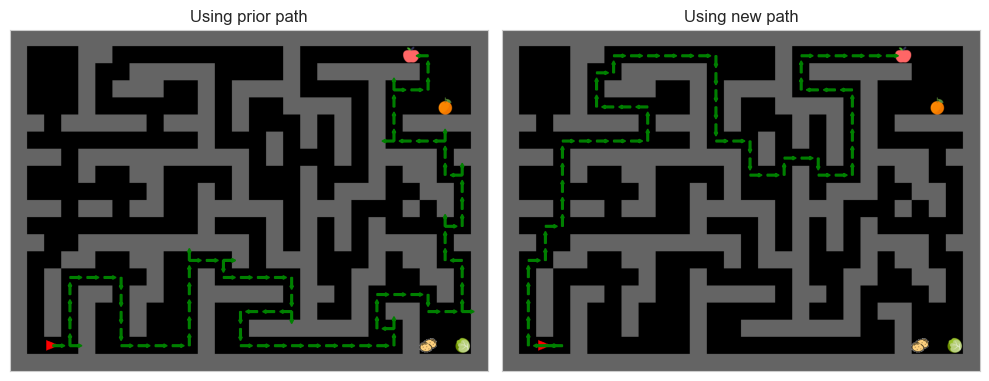

In [382]:
plots.plot_m3_example(m3_df, finished=True)

In [342]:
# mazes = [
#     'big_m3_maze1_(F,F)',
#     'big_m3_maze1_(F,T)',
#     'big_m3_maze1_(T,F)',
#     'big_m3_maze1_(T,T)',
# ]

# users = user_df.filter(manipulation=3)['user'].unique()
# for user in users:
#     train = user_df.filter(user=user, maze='big_m3_maze1_(F,T)', room=0, eval=False, episode_filter= lambda e: not housemaze.success(e))
#     test = user_df.filter(user=user, maze='big_m3_maze1_(F,T)', eval=True)

#     train_map = housemaze.create_maps(train.episodes).sum(0)
#     test_map = housemaze.create_maps(test.episodes).sum(0)

#     overlap = housemaze.overlap(train_map, test_map)
#     reused = overlap.mean() > .25
#     if not reused:
#         print("-"*50)
#         housemaze.render_path(train.episodes[0])
#         housemaze.render_path(test.episodes[0])
#         plt.show()
#         print(overlap.mean(), )


/Users/wilka/git/research/human-dyna-web/analysis/plots.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha='right')


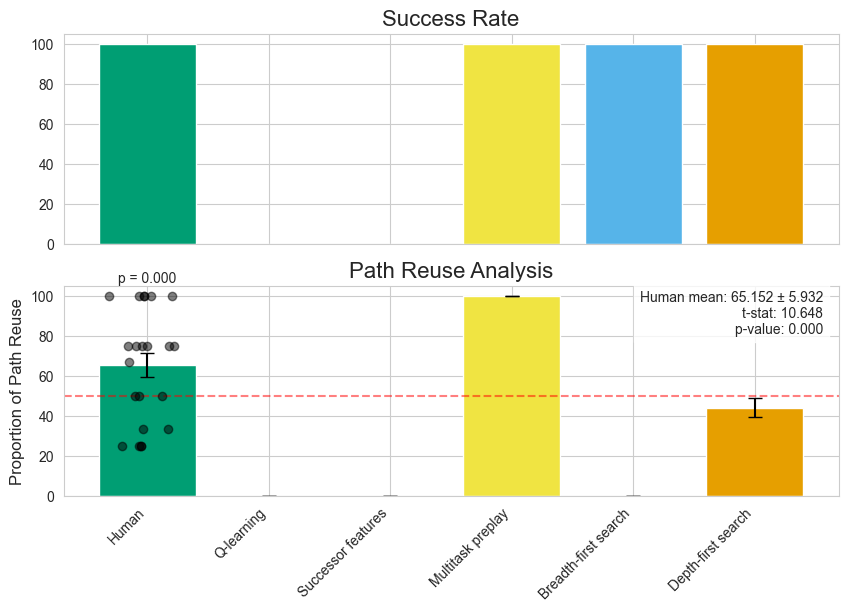

In [383]:
# plots.create_bar_plot_results_m3(user_df, model_df)
fig, axs = plt.subplots(2, 1, figsize=(10, 6))
plots.create_success_termination_results_m3(m3_df, model_df, ax=axs[0])
plots.create_bar_plot_results_m3(m3_df, model_df, ax=axs[1])
_ = axs[0].set_xticklabels([])

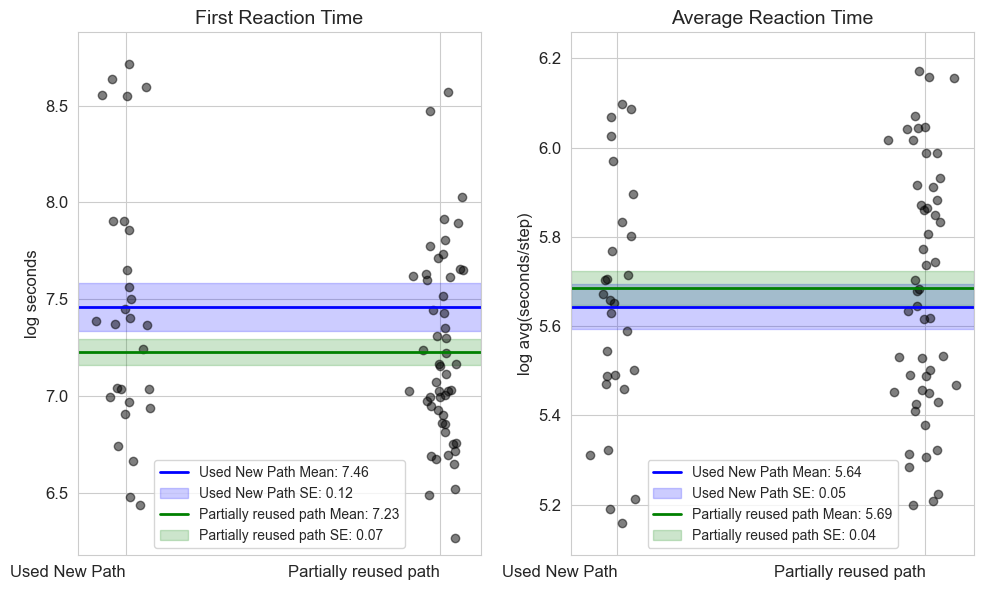

In [486]:
plots.m3_reaction_times(m3_df)

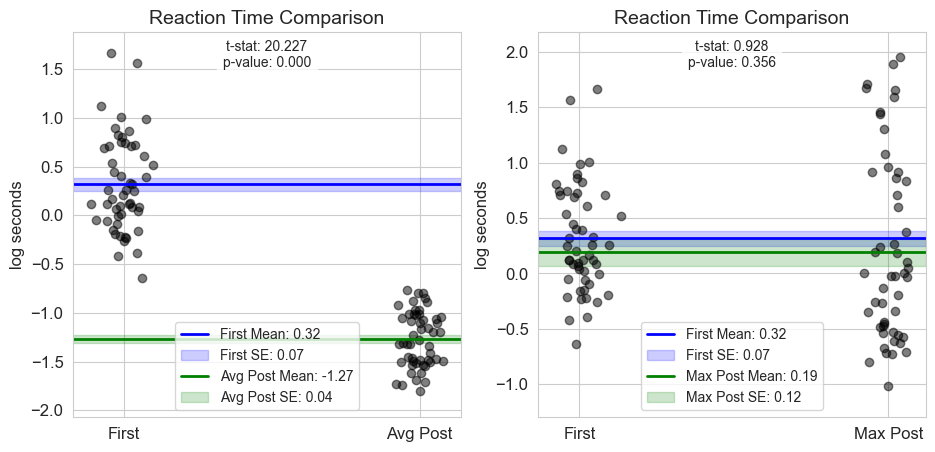

In [487]:
fig, axs = plt.subplots(1, 2, figsize=(11, 5))

reused = m3_df.filter(manipulation=3, reuse=True)
first_rt = reused["first_rt"].to_numpy()
post_rt1 = np.array([np.mean(plots.post_first_rt(e)) for e in reused.episodes])
post_rt2 = np.array([np.max(plots.post_first_rt(e)) for e in reused.episodes])
plots.plot_compare_rt(first_rt, post_rt1, "First", "Avg Post", ax=axs[0])
plots.plot_compare_rt(first_rt, post_rt2, "First", "Max Post", ax=axs[1])

## (B) Shortcut manipulation (1)

In [376]:
settings = dict(manipulation=1, eval=True)
m1_df = plots.filter_outliers(
  df=user_df,
  filter_settings=settings,
  filter_columns=["path_length", "total_rt"],
)
# for val in ['path_length', 'first_rt', 'avg_rt']:
#     plots.coplot_dists(user_df, filtered_df, val, settings)

Filtered 12 outliers from 92 rows using iqr method
	36431270. path_length:230 	(bounds: 16.5 to 148.5)
	36431270. path_length:151 	(bounds: 16.5 to 148.5)
	36431270. path_length:173 	(bounds: 16.5 to 148.5)
	322916660. total_rt:42.10499954223633 	(bounds: 1.6718754768371582 to 41.872875690460205)
	322916660. path_length:190 	(bounds: 16.5 to 148.5)
	322916660. total_rt:70.83999633789062 	(bounds: 1.6718754768371582 to 41.872875690460205)
	322916660. total_rt:50.69999694824219 	(bounds: 1.6718754768371582 to 41.872875690460205)
	3903080245. path_length:179 	(bounds: 16.5 to 148.5)
	3903080245. total_rt:53.356998443603516 	(bounds: 1.6718754768371582 to 41.872875690460205)
	3903080245. path_length:163 	(bounds: 16.5 to 148.5)
	3903080245. total_rt:47.540000915527344 	(bounds: 1.6718754768371582 to 41.872875690460205)
	3903080245. path_length:153 	(bounds: 16.5 to 148.5)
	3903080245. total_rt:43.11000061035156 	(bounds: 1.6718754768371582 to 41.872875690460205)
	3903080245. total_rt:42.71

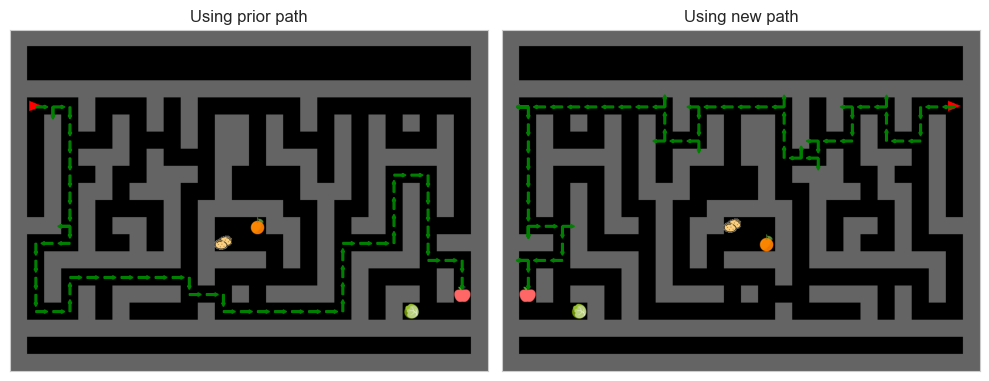

In [335]:
plots.plot_m1_example(m1_df)

/Users/wilka/git/research/human-dyna-web/analysis/plots.py:104: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha='right')


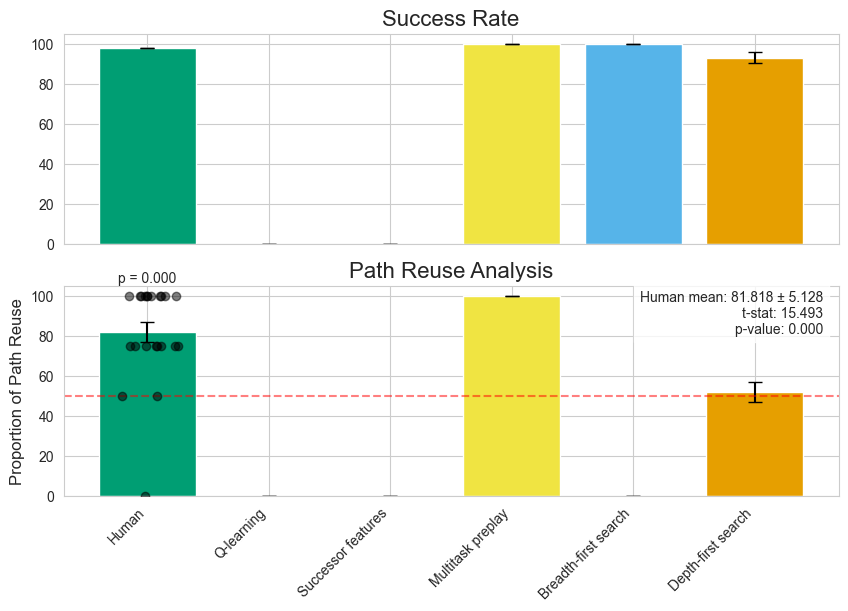

In [377]:
# plots.create_bar_plot_results_m3(user_df, model_df)
fig, axs = plt.subplots(2, 1, figsize=(10, 6))
plots.create_success_termination_results_m1(m1_df, model_df, ax=axs[0])
plots.create_bar_plot_results_m1(m1_df, model_df, ax=axs[1])
_ = axs[0].set_xticklabels([])

Filtered 1 outliers from 65 episodes
Filtered 1 outliers from 65 episodes


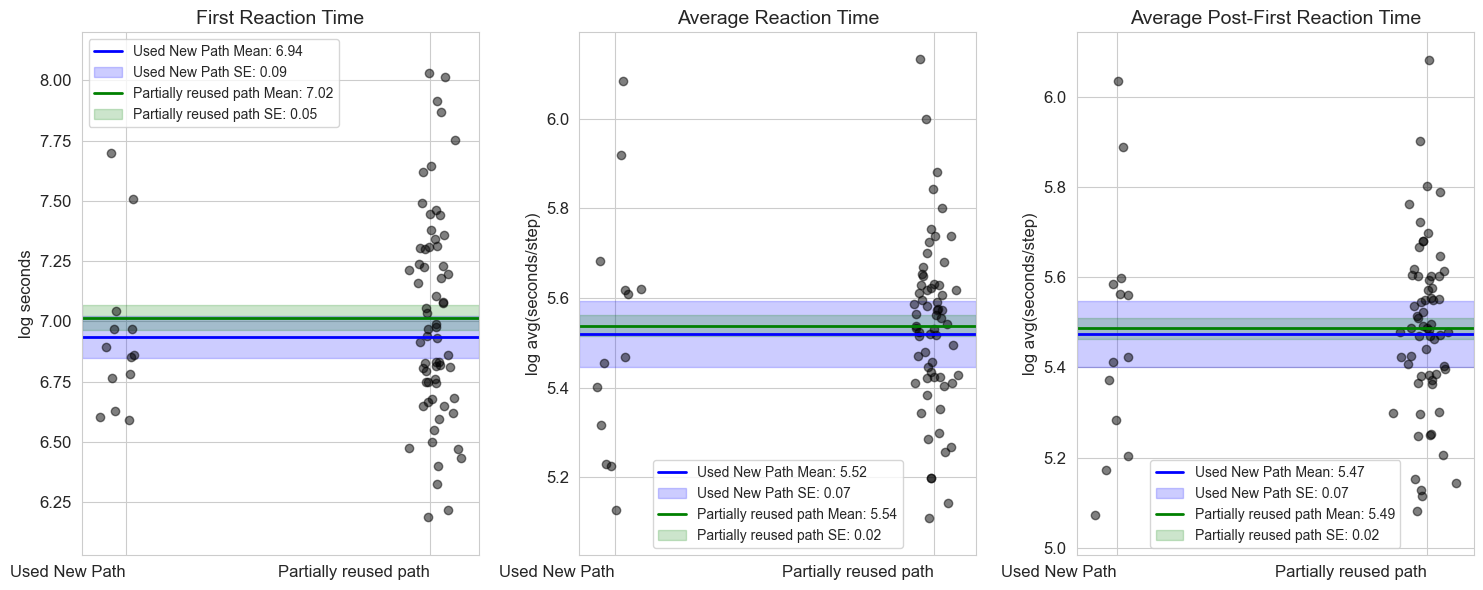

In [393]:
# plots.m1_reaction_times(user_df, rt_types=['first', 'speed', 'total'])
plots.m1_reaction_times(m1_df, rt_types=["first", "speed"])

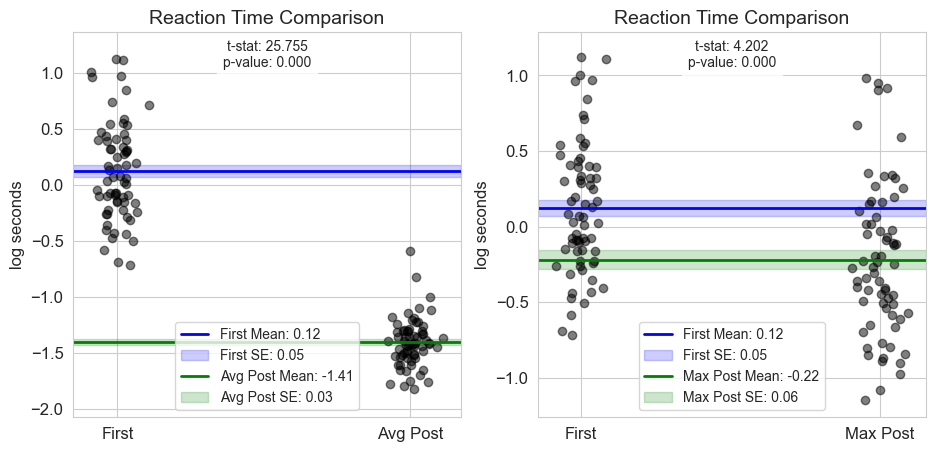

In [387]:
fig, axs = plt.subplots(1, 2, figsize=(11, 5))

reused = m1_df.filter(manipulation=1, reuse=True)
first_rt = reused["first_rt"].to_numpy()
post_rt1 = np.array([np.mean(plots.post_first_rt(e)) for e in reused.episodes])
post_rt2 = np.array([np.max(plots.post_first_rt(e)) for e in reused.episodes])
plots.plot_compare_rt(first_rt, post_rt1, "First", "Avg Post", ax=axs[0])
plots.plot_compare_rt(first_rt, post_rt2, "First", "Max Post", ax=axs[1])

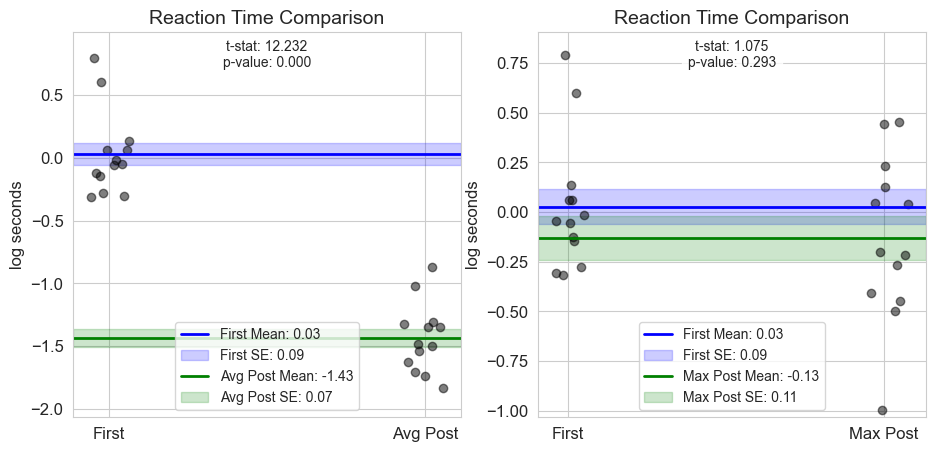

In [388]:
fig, axs = plt.subplots(1, 2, figsize=(11, 5))

reused = filtered_df.filter(manipulation=1, reuse=False)
first_rt = reused["first_rt"].to_numpy()
post_rt1 = np.array([np.mean(plots.post_first_rt(e)) for e in reused.episodes])
post_rt2 = np.array([np.max(plots.post_first_rt(e)) for e in reused.episodes])
plots.plot_compare_rt(first_rt, post_rt1, "First", "Avg Post", ax=axs[0])
plots.plot_compare_rt(first_rt, post_rt2, "First", "Max Post", ax=axs[1])

In [394]:
# cond1 = filtered_df.filter(manipulation=1, eval=True, reuse=False).episodes
# cond2 = filtered_df.filter(manipulation=1, eval=True, reuse=True).episodes

# # housemaze.create_episode_reaction_times_video(cond1[1])
# for e in cond1[:5]:
#     housemaze.render_path(e)

# for e in cond2[:5]:
#     housemaze.render_path(e)


In [395]:
# cond1 = filtered_df.filter(manipulation=1, eval=True, reuse=False).episodes
# cond2 = filtered_df.filter(manipulation=1, eval=True, reuse=True).episodes

# # housemaze.create_episode_reaction_times_video(cond1[1])
# for e in cond1[:5]:
#     housemaze.create_episode_reaction_times_video(e)
# for e in cond2[:5]:
#     housemaze.create_episode_reaction_times_video(e)


## (C) Starting point manipulation (2)

In [418]:
settings = dict(manipulation=2, eval=True)
m2_df = user_df
# m2_df = plots.filter_outliers(
#     df=user_df,
#     filter_settings=settings,
#     filter_columns=['path_length', 'first_rt'],
# )
# for val in ['path_length', 'first_rt', 'avg_rt']:
#     plots.coplot_dists(user_df, filtered_df, val, settings)

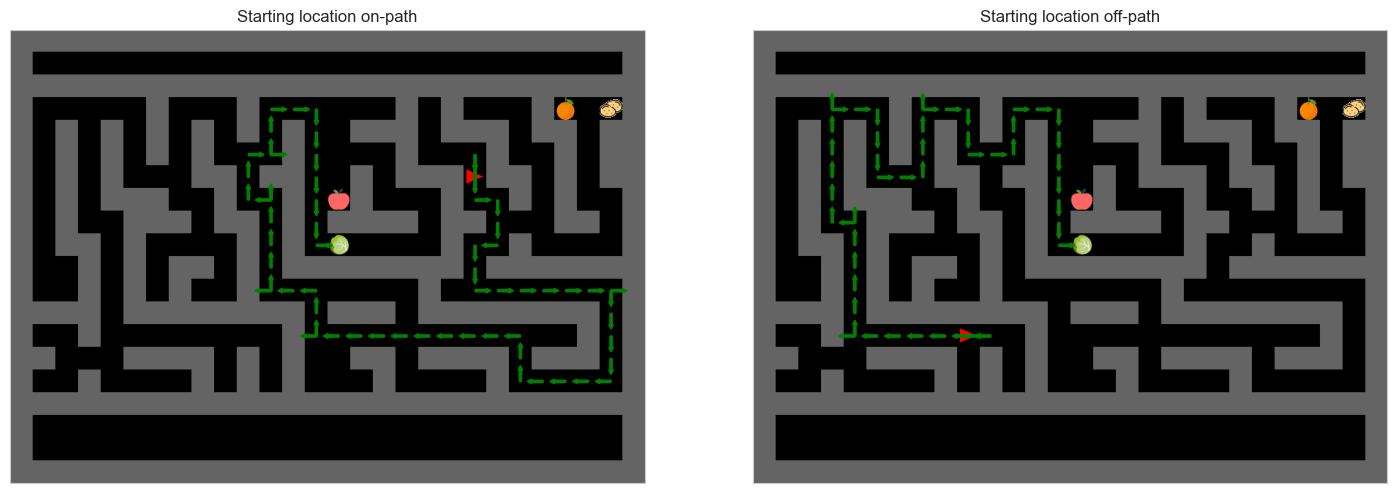

In [419]:
plots.plot_m2_example(m2_df)

Skipping 2040342950: 4 != 3
Skipping 1372081707: 2 != 4
Skipping 2140518989: 3 != 4
Skipping 377550045: 3 != 1
Skipping 3128695661: 3 != 4
Filtered 19 outliers


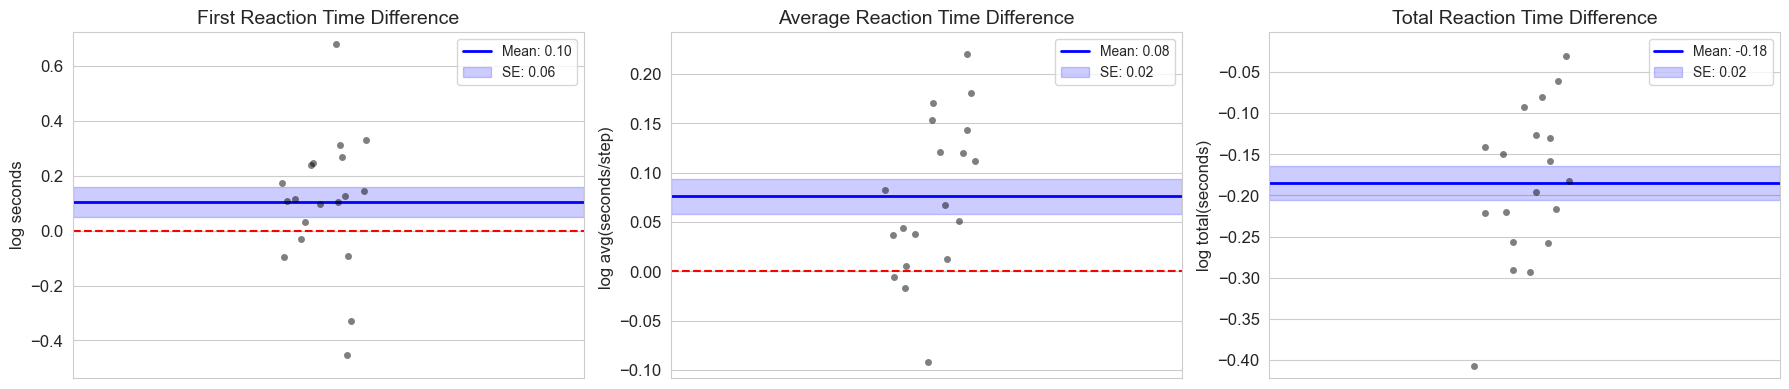

In [420]:
# plots.m2_reaction_time_difference(user_df, ['first', 'avg', 'total'], filter_outliers=False)
plots.m2_reaction_time_difference(
  user_df, ["first", "avg", "total"], filter_outliers=True
)

## (D) Planning manipulation (4) - short

In [468]:
user_df.filter(manipulation=4, tell_reuse=1)["maze"].unique()

maze
str
"""big_m4_maze_long_eval_same_(T,…"
"""big_m4_maze_long_eval_same_(T,…"
"""big_m4_maze_short_eval_diff_(F…"
"""big_m4_maze_long_(F,F)"""
"""big_m4_maze_long_(T,F)"""
…
"""big_m4_maze_short_eval_same_(T…"
"""big_m4_maze_long_eval_diff_(T,…"
"""big_m4_maze_short_eval_diff_(T…"


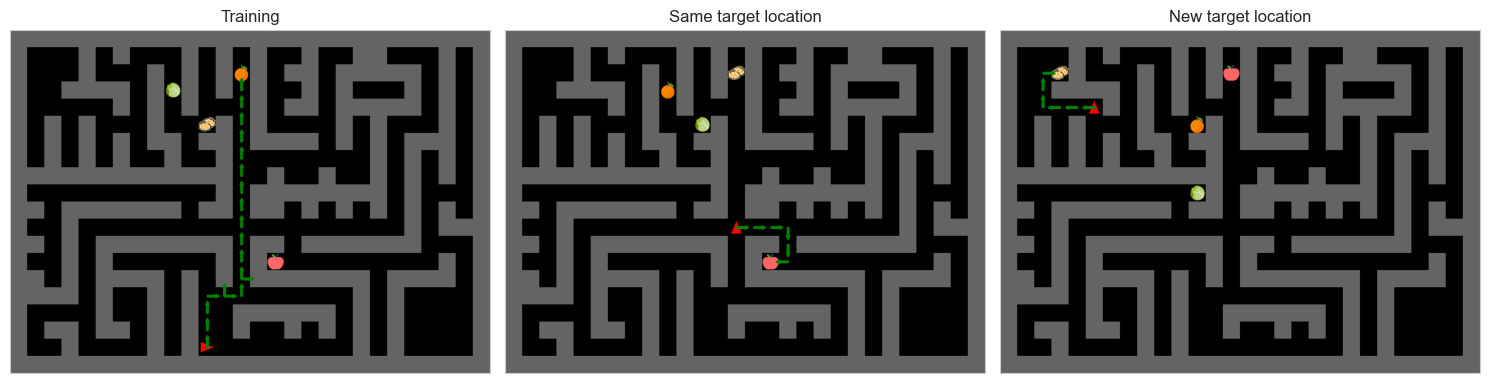

In [473]:
plots.plot_m4_example(user_df, "short")

Filtered 14 outliers


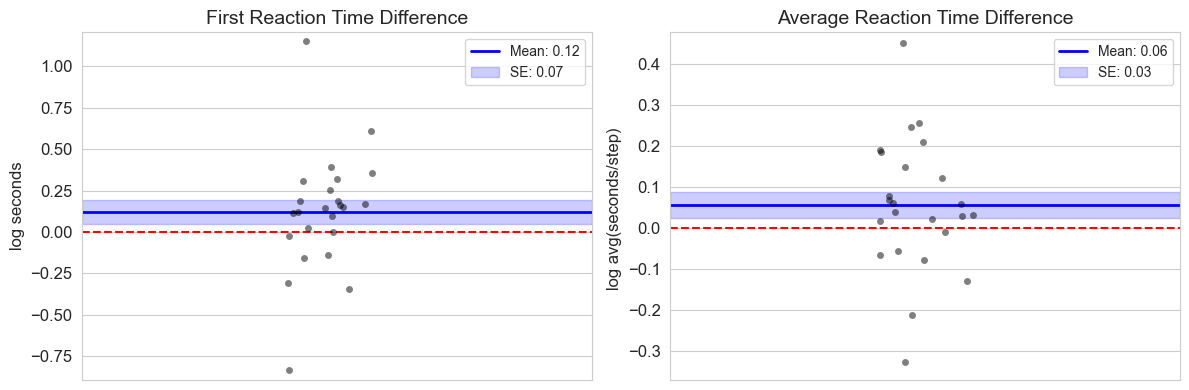

In [479]:
# # SHORT, TELL
# plots.m4_reaction_time_difference(
#     user_df, setting='short', rt_types=['first', 'avg', 'total'], filter_outliers=False,
#     extra_settings=dict(tell_reuse=1),
# )
plots.m4_reaction_time_difference(
  user_df,
  setting="short",
  rt_types=["first", "avg"],
  filter_outliers=True,
  extra_settings=dict(tell_reuse=1),
)

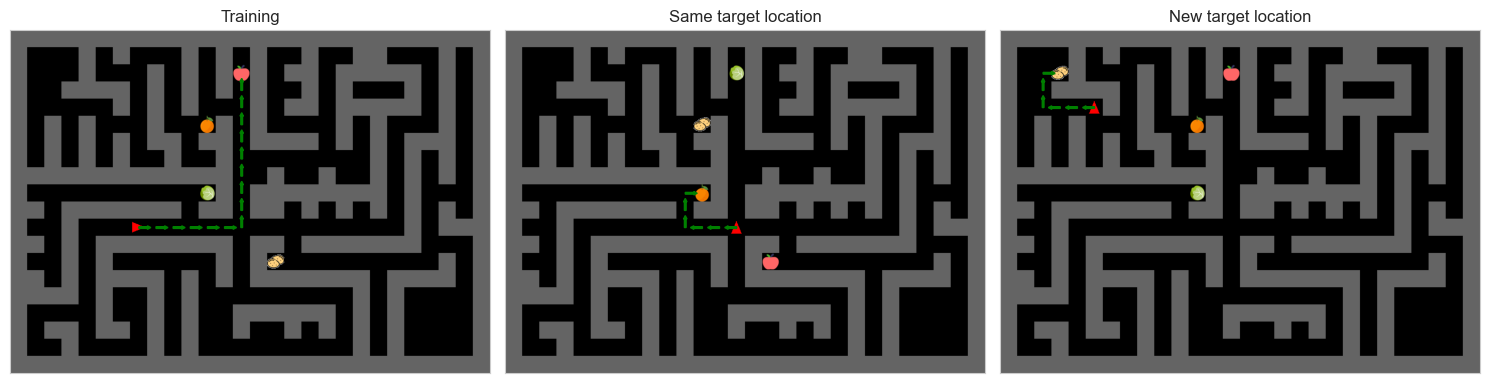

In [476]:
plots.plot_m4_example(user_df, "short", "blind")

Skipping 6756109: 4 != 3
Skipping 3812861288: 1 != 2
Filtered 14 outliers


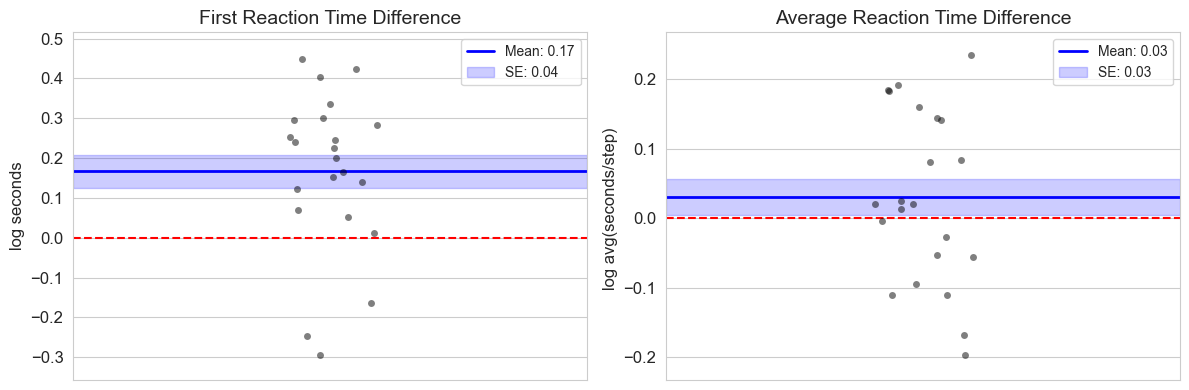

In [480]:
# plots.m4_reaction_time_difference(
#     user_df, setting='short', rt_types=['first', 'avg', 'total'], filter_outliers=False,
#     extra_settings=dict(tell_reuse=0),
#     version='blind',
# )
plots.m4_reaction_time_difference(
  user_df,
  setting="short",
  rt_types=["first", "avg"],
  filter_outliers=True,
  extra_settings=dict(tell_reuse=0),
  version="blind",
)

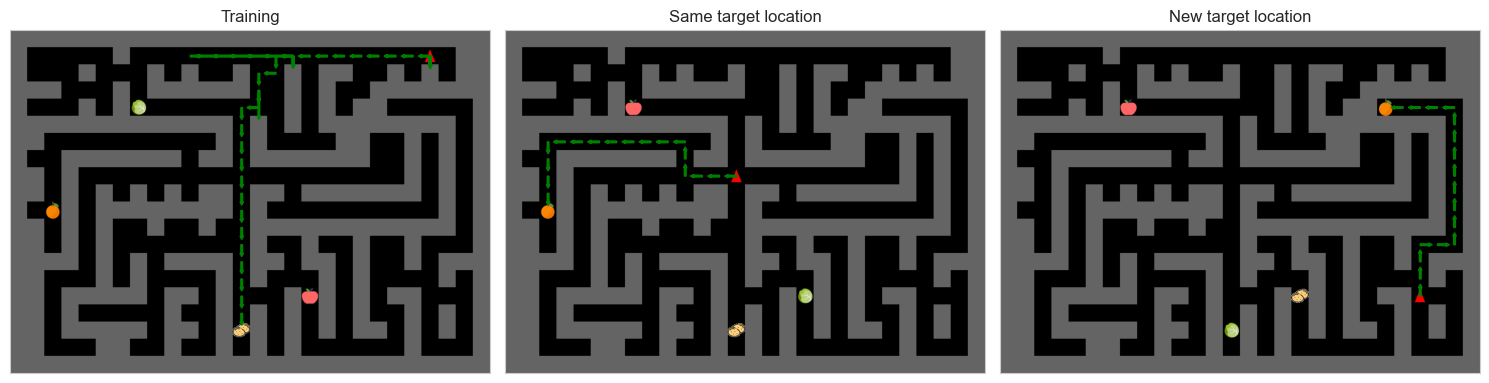

In [475]:
plots.plot_m4_example(user_df, "long")

In [1]:
# LONG, TELL
# plots.m4_reaction_time_difference(user_df, setting='long', rt_types=['first', 'avg'], filter_outliers=False)
# plots.m4_reaction_time_difference(
#     user_df, setting='long', rt_types=['first', 'avg', 'total'], filter_outliers=False,
#     extra_settings=dict(tell_reuse=1),
# )
plots.m4_reaction_time_difference(
  user_df,
  setting="long",
  rt_types=["first", "avg"],
  filter_outliers=False,
  extra_settings=dict(tell_reuse=1),
)

NameError: name 'plots' is not defined

In [ ]:
# SHORT, DON'T TELL

Skipping 6756109: 4 != 3
Skipping 3812861288: 1 != 2


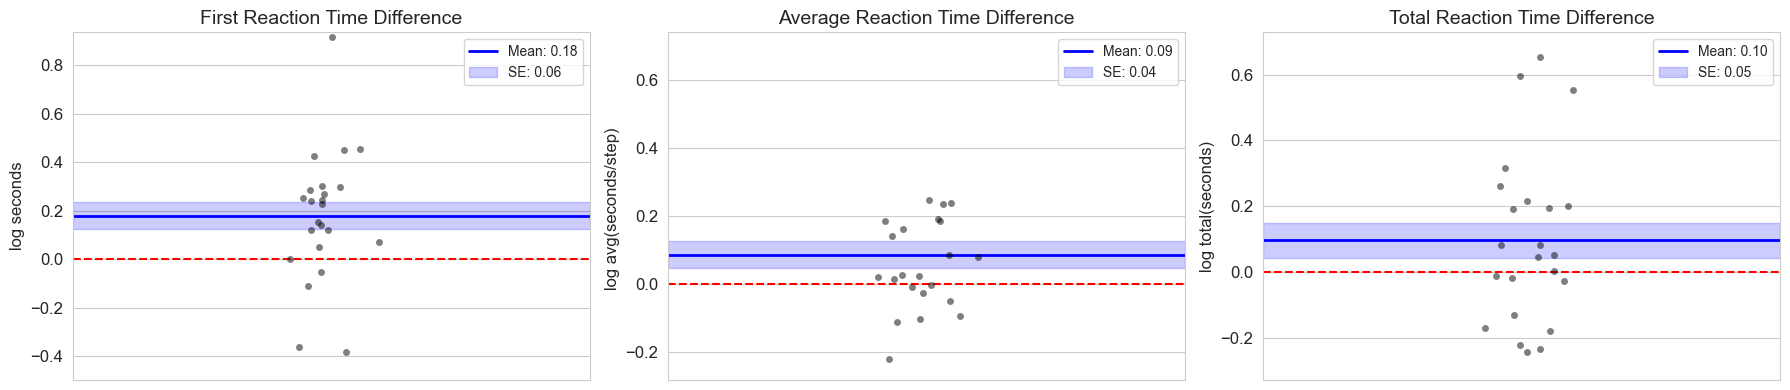

Skipping 6756109: 4 != 3
Skipping 3812861288: 1 != 2
Filtered 14 outliers


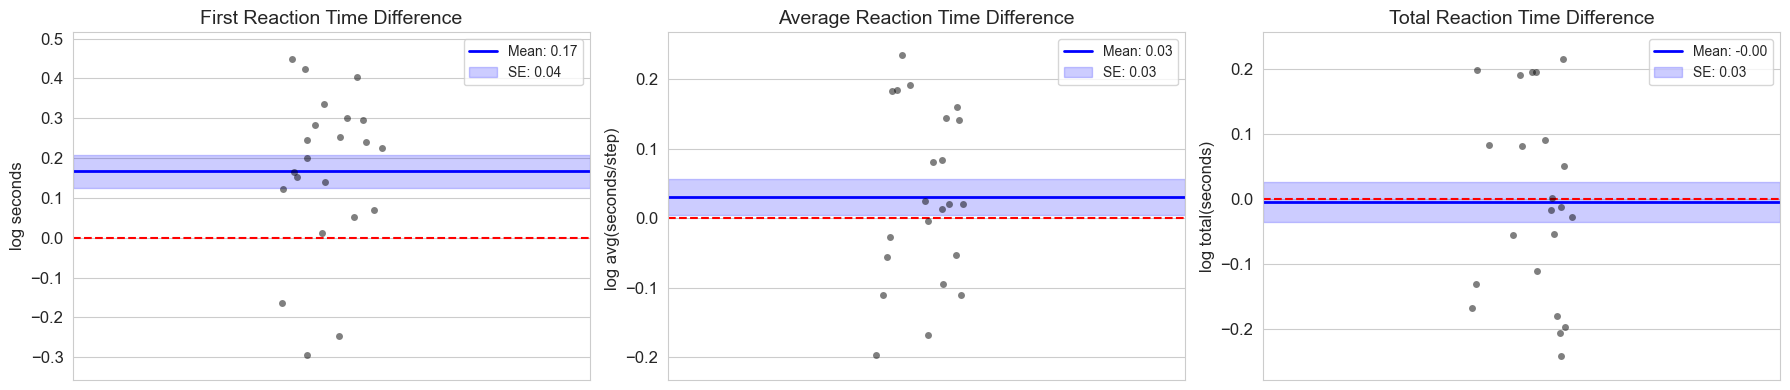

In [448]:
# plots.m4_reaction_time_difference(
#     user_df, setting='long', rt_types=['first', 'avg', 'total'], filter_outliers=True,
#     extra_settings=dict(tell_reuse=0),
#     version='blind',
# )

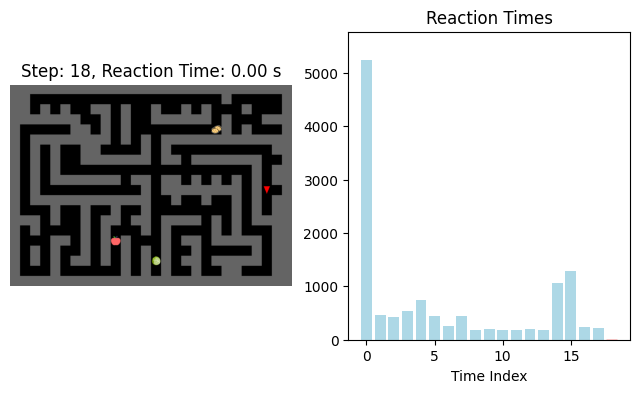

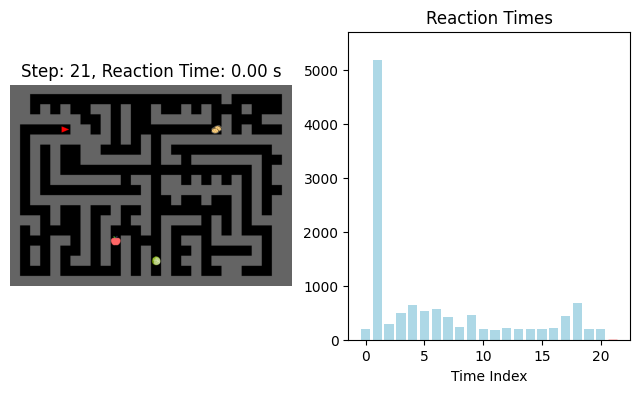

In [121]:
setting = "long"
subset = user_df.filter_by_group(
  input_episode_filter=partial(plots.group_filter_fn, min_successes=8),
  output_episode_filter=lambda e: not success_or_not_terminate(e),
  input_settings=dict(eval=False, name=f"big_m4_maze_{setting}"),
  output_settings=dict(manipulation=4),
)
user = subset["user_id"].unique()[3]
cond0 = subset.filter(name=f"big_m4_maze_{setting}", user=user)
cond1 = subset.filter(name=f"big_m4_maze_{setting}_eval_same", user=user)
cond2 = subset.filter(name=f"big_m4_maze_{setting}_eval_diff", user=user)

housemaze.create_episode_reaction_times_video(cond1.episodes[2])
housemaze.create_episode_reaction_times_video(cond2.episodes[2])

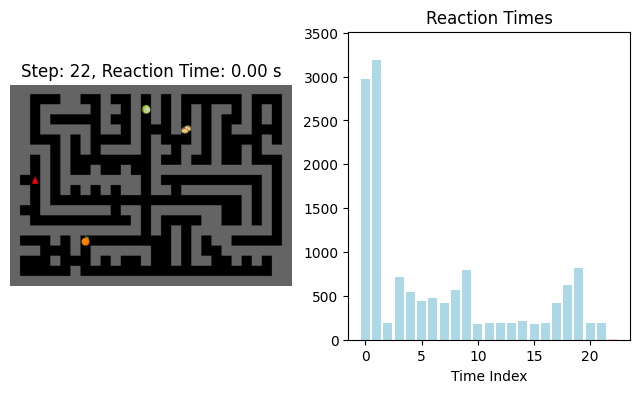

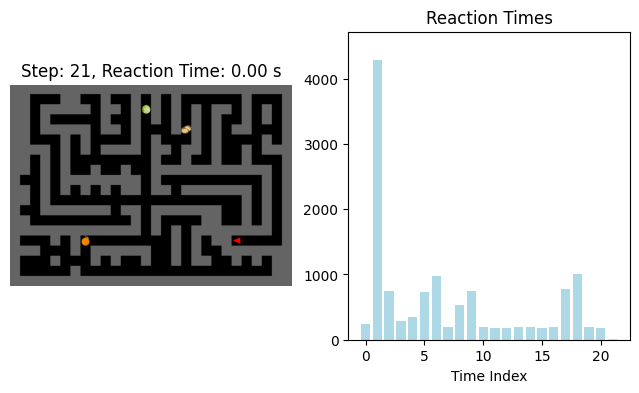

In [86]:
housemaze.create_episode_reaction_times_video(cond1.episodes[1])
housemaze.create_episode_reaction_times_video(cond2.episodes[1])

# Training statistics

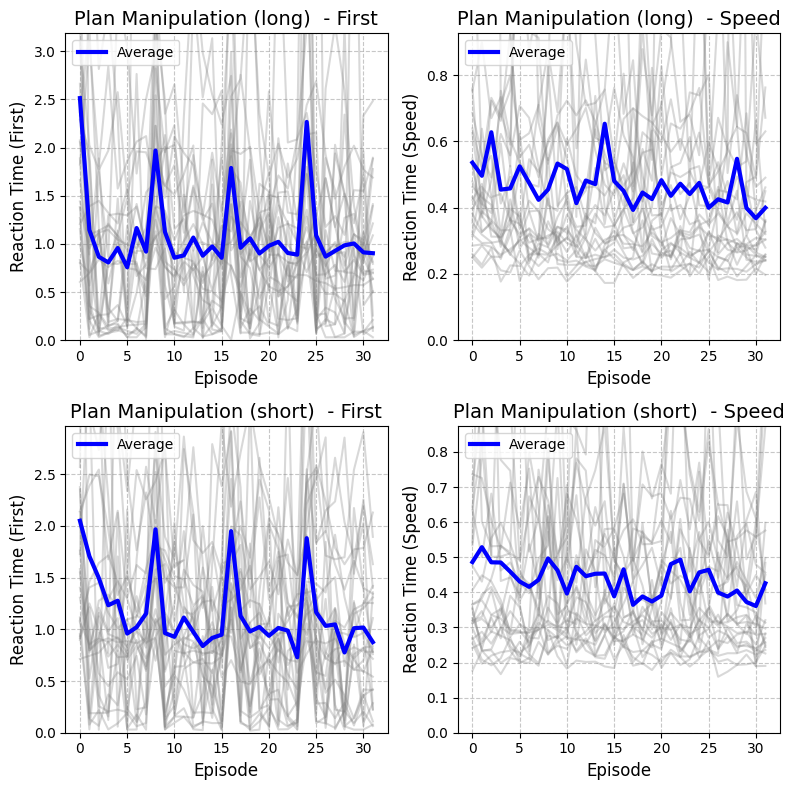

In [80]:
# plots.plot_train_reaction_times_dual(user_df)

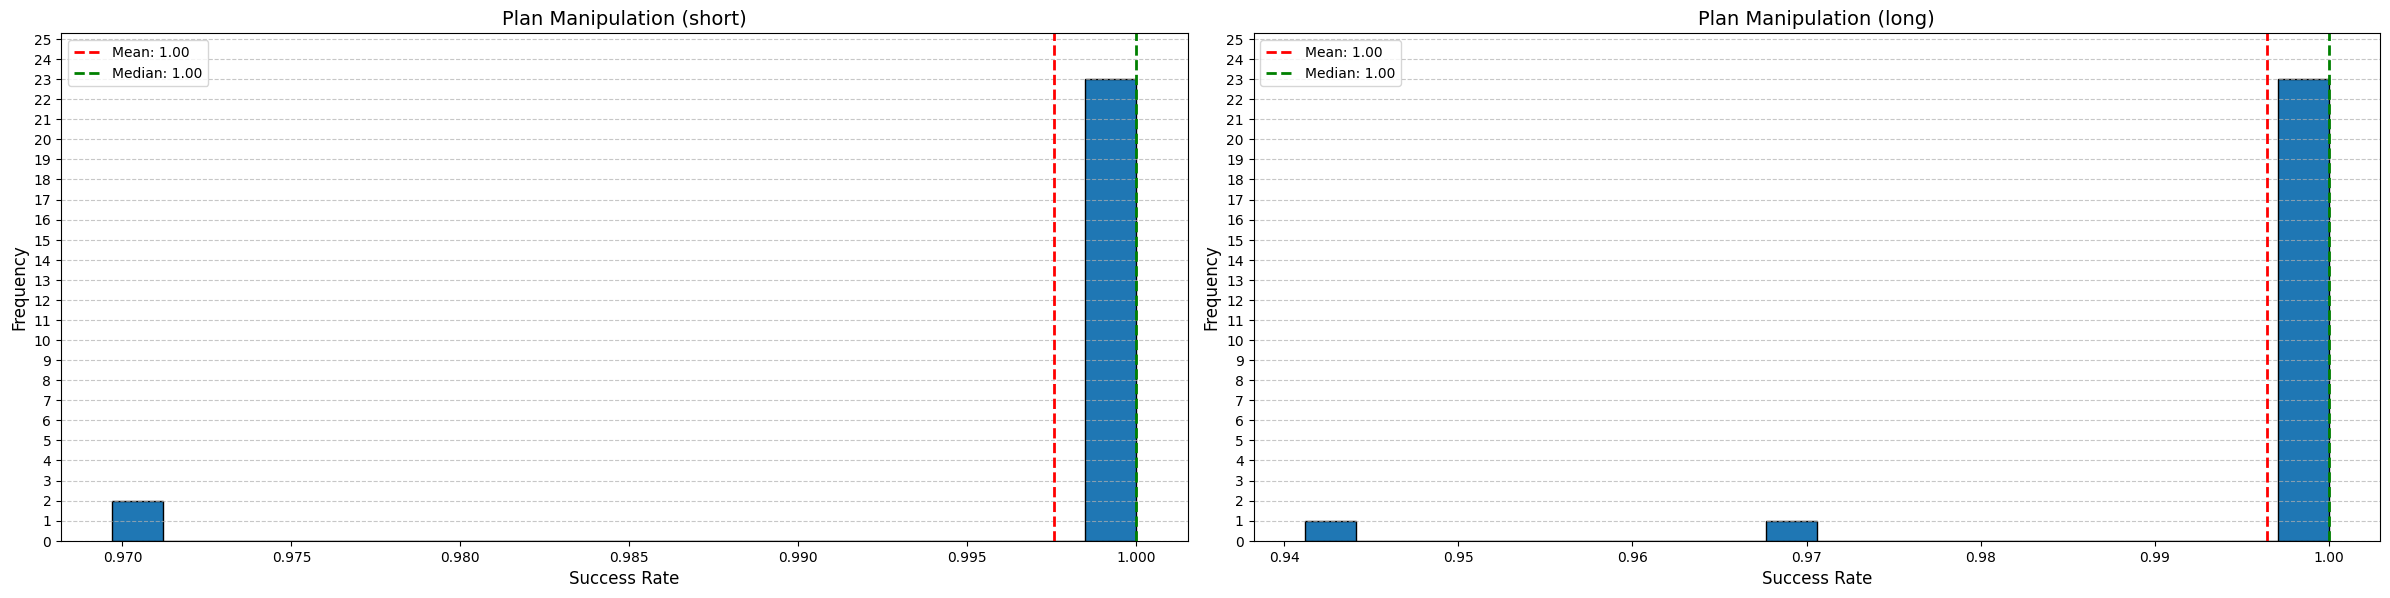

In [79]:
plots.plot_train_success_rate_histograms(user_df)

In [180]:
# plots.plot_episode_counts(user_df)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (802,) + inhomogeneous part.

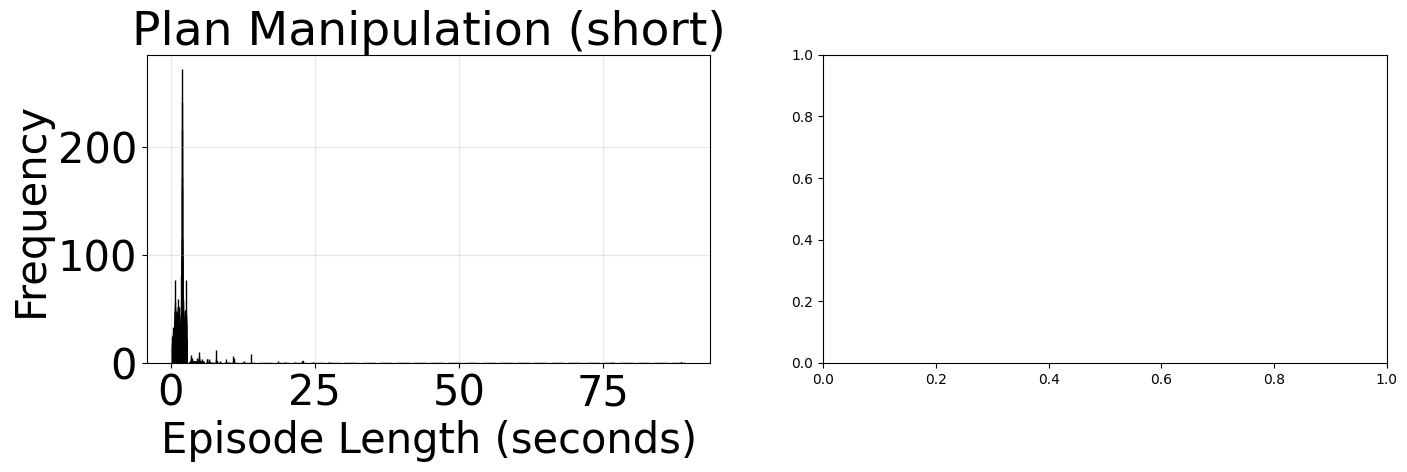

In [81]:
# plots.plot_episode_length_seconds(user_df, title_size=34, label_size=30)